# Chapter 1 (extra): Numerical inversion of Laplace transforms (Gaver–Stehfest)

The Laplace-transform method turns a diffusion PDE into an ODE in the transform
variable $s$, which is usually easy to solve. The hard step is the *inverse*
transform back to the time domain. For many electrochemical problems the
transform $\bar f(s)$ is known in closed form but its inverse is not available
from tables or from a symbolic engine (for example, when $\bar f$ is an infinite sum, or
contains awkward $\sqrt s$ / $\coth\sqrt s$ factors from finite or spherical
geometries).

The **Gaver–Stehfest** algorithm (Stehfest, *Comm. ACM* **13** (1970) 47–49 and
624) sidesteps this. It reconstructs $f(t)$ from a handful of *real* samples of
$\bar f(s)$ on the positive real axis,

$$
f(t)\;\approx\;\frac{\ln 2}{t}\sum_{k=1}^{N} V_k\,
              \bar f\!\Big(\frac{k\ln 2}{t}\Big),
$$

with weights $V_k$ that depend only on $N$ (even). No complex arithmetic and no
contour integration are needed: only $N$ evaluations of $\bar f$ on the real
line per time point. The book reaches for a third-party Mathematica package for
exactly this. Here we re-implement the algorithm from the defining series and
validate it against closed forms we can check independently.

This notebook is self-contained. It reuses `serm.echem.cottrell_current` only as
an independent dimensional cross-check.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

# %matplotlib inline embeds figures and makes plt.show() a no-op under headless (Agg).
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy.special import erf, erfc

import serm
from serm.echem import cottrell_current

np.set_printoptions(precision=6, suppress=True)

In [2]:
from serm.sourcelinks import source_links
source_links(cottrell_current)

## The Stehfest weights

The weights come from a finite-difference approximation to the Bromwich
integral. With $N$ even and $N/2 \equiv M$,

$$
V_k = (-1)^{k+M}\!\!\sum_{j=\lfloor (k+1)/2\rfloor}^{\min(k,M)}
      \frac{j^{M}\,(2j)!}
           {(M-j)!\,j!\,(j-1)!\,(k-j)!\,(2j-k)!}.
$$

They alternate in sign and grow rapidly in magnitude with $N$, which is why
very large $N$ eventually loses accuracy to floating-point cancellation. In
double precision the sweet spot is typically $N \approx 12\text{–}16$. The
weights satisfy $\sum_k V_k = 0$ (they reconstruct decaying transforms), a cheap
self-check.

*Scope.* Gaver–Stehfest is reliable for **smooth, monotone** transforms such as the diffusion responses inverted here. It degrades badly on oscillatory transforms (for example, ones with poles on the imaginary axis), where contour-integral methods are preferable.

In [3]:
def stehfest_weights(N: int) -> np.ndarray:
    """Gaver-Stehfest weights V_k for an even number of terms ``N``.

    Parameters
    ----------
    N : int
        Number of terms (must be even). Practical range 8-16 in float64.

    Returns
    -------
    numpy.ndarray
        The weights ``V[0..N-1]`` (V_k for k = 1..N).
    """
    if N % 2 != 0:
        raise ValueError("Stehfest N must be even.")
    M = N // 2
    V = np.zeros(N)
    for k in range(1, N + 1):
        acc = 0.0
        for j in range((k + 1) // 2, min(k, M) + 1):
            acc += (j ** M * factorial(2 * j)
                    / (factorial(M - j) * factorial(j) * factorial(j - 1)
                       * factorial(k - j) * factorial(2 * j - k)))
        V[k - 1] = (-1) ** (k + M) * acc
    return V


# Self-check: the weights of a Stehfest scheme sum to zero.
for N in (8, 12, 16):
    assert abs(stehfest_weights(N).sum()) < 1e-6, N
print("PASS: sum_k V_k = 0 for N = 8, 12, 16 (decaying-transform consistency).")

PASS: sum_k V_k = 0 for N = 8, 12, 16 (decaying-transform consistency).


## The inversion routine

Given a transform $\bar f(s)$ (a vectorised callable accepting an array of real
$s$) and a time grid, the inverse is a single weighted sum per time point.

In [4]:
def stehfest_invert(F, t, N: int = 14) -> np.ndarray:
    """Gaver-Stehfest numerical inverse Laplace transform.

    Reconstructs ``f(t)`` from real-axis samples of the transform ``F(s)``.

    Parameters
    ----------
    F : callable
        Vectorised Laplace transform ``F(s)`` accepting an ndarray of real s.
    t : array_like
        Time point(s), strictly positive.
    N : int
        Even number of terms (default 14).

    Returns
    -------
    numpy.ndarray
        Approximate ``f(t)``, same shape as ``t``.
    """
    t = np.atleast_1d(np.asarray(t, dtype=float))
    if np.any(t <= 0):
        raise ValueError("Stehfest inversion requires t > 0.")
    V = stehfest_weights(N)
    k = np.arange(1, N + 1)
    ln2 = np.log(2.0)
    out = np.empty_like(t)
    for i, ti in enumerate(t):
        a = ln2 / ti
        out.flat[i] = a * np.dot(V, F(k * a))
    return out

## Validation 1: elementary transforms (closed-form analytic, strongest tier)

Two textbook pairs check the machinery end to end:

* $\bar f(s) = 1/s \;\Rightarrow\; f(t) = 1$ (a constant; tests the $s\to 0$
  behaviour),
* $\bar f(s) = 1/(s+a) \;\Rightarrow\; f(t) = e^{-a t}$ (a decaying exponential).

In [5]:
# 1/s -> 1
t1 = np.array([0.25, 1.0, 4.0, 16.0])
unit = stehfest_invert(lambda s: 1.0 / s, t1, N=14)
print("1/s  -> f(t):", unit)
assert np.allclose(unit, 1.0, atol=1e-6)

# 1/(s+a) -> exp(-a t)
a = 1.7
t2 = np.array([0.1, 0.5, 1.0, 2.0, 4.0])
expo = stehfest_invert(lambda s: 1.0 / (s + a), t2, N=14)
err_exp = np.max(np.abs(expo - np.exp(-a * t2)))
print(f"1/(s+a) max abs err = {err_exp:.2e}")
assert err_exp < 1e-4
print("PASS: Stehfest recovers 1 and exp(-a t) (closed-form analytic tier).")

1/s  -> f(t): [1. 1. 1. 1.]
1/(s+a) max abs err = 2.55e-05
PASS: Stehfest recovers 1 and exp(-a t) (closed-form analytic tier).


## Validation 2: the semi-infinite potential step (the book's example)

This is the example Honeychurch inverts symbolically and then numerically. For a
potential step to the diffusion-limited region with $c(0,t)=0$, $c(\infty,t)=c^\ast$,
the transform of the concentration profile is

$$
\bar c(x,s) = \frac{c^\ast}{s} - \frac{c^\ast}{s}\,
              \exp\!\Big(\!-\sqrt{\tfrac{s}{D}}\;x\Big),
$$

whose exact inverse is the error-function profile
$c(x,t) = c^\ast\,\mathrm{erf}\!\big(x/2\sqrt{Dt}\big)$, derived and validated
in the main Chapter 1 notebook. We invert the transform numerically and compare
to that closed form (reduction to a validated limit / closed-form analytic
tier).

In [6]:
c_star, D = 1.0, 1e-5            # cm^2/s; dimensional, as in the book
x = 5e-4                          # cm (a representative depth)

def cbar_step(s):
    """Laplace transform of the semi-infinite step concentration profile."""
    return c_star / s - c_star * np.exp(-np.sqrt(s / D) * x) / s

t_grid = np.array([0.001, 0.01, 0.1, 1.0])
c_num = stehfest_invert(cbar_step, t_grid, N=16)
c_ana = c_star * erf(x / (2.0 * np.sqrt(D * t_grid)))
print("t        :", t_grid)
print("numerical:", c_num)
print("erf exact:", c_ana)
err_prof = np.max(np.abs(c_num - c_ana))
print(f"max abs err = {err_prof:.2e}")
assert err_prof < 1e-4
print("PASS: Stehfest inversion reproduces the erf concentration profile.")

t        : [0.001 0.01  0.1   1.   ]
numerical: [0.999595 0.736445 0.276326 0.089021]
erf exact: [0.999593 0.736448 0.276326 0.089021]
max abs err = 2.20e-06
PASS: Stehfest inversion reproduces the erf concentration profile.


### The surface flux: a Cottrell cross-check

Differentiating the transform with respect to $x$ and evaluating at the
electrode ($x=0$) gives the transform of the concentration *gradient*,
$\partial_x\bar c(0,s) = c^\ast/\sqrt{sD}$. The diffusive flux magnitude is
$D\,\partial_x c(0,t)$, whose transform is $c^\ast\sqrt{D/s}\cdot s^{0}$; more
simply, inverting $c^\ast/\sqrt{sD}$ gives $c^\ast/\sqrt{\pi D t}$, so the flux is

$$
D\,\partial_x c(0,t) = c^\ast\sqrt{\tfrac{D}{\pi t}},
$$

the **Cottrell** result. We invert numerically and compare both to the analytic
form and, dimensionally, to `serm.echem.cottrell_current`.

In [7]:
def grad_bar(s):
    """Transform of the surface concentration gradient dc/dx|_{x=0}."""
    return c_star / np.sqrt(s * D)

t_f = np.array([0.01, 0.1, 1.0])
grad_num = stehfest_invert(grad_bar, t_f, N=14)
flux_num = D * grad_num                        # diffusive flux magnitude
flux_ana = c_star * np.sqrt(D / (np.pi * t_f))
rel = np.max(np.abs(flux_num / flux_ana - 1.0))
print("flux numerical:", flux_num)
print("flux analytic :", flux_ana)
print(f"max rel err = {rel:.2e}")
assert rel < 1e-4

# Independent dimensional cross-check against serm.echem.cottrell_current.
# i(t) = n F A * (D dc/dx) with c_bulk = c_star; pick unit n, A.
n, A = 1, 1.0
i_stehfest = n * serm.echem.F * A * flux_num
i_echem = cottrell_current(t_f, n=n, A=A, D=D, c_bulk=c_star)
ratio = i_stehfest / i_echem
print("i_stehfest / i_echem =", ratio)
assert np.allclose(ratio, 1.0, rtol=1e-4)
print("PASS: inverted surface flux is the Cottrell current "
      "(matches serm.echem.cottrell_current).")

flux numerical: [0.017841 0.005642 0.001784]
flux analytic : [0.017841 0.005642 0.001784]
max rel err = 1.16e-07
i_stehfest / i_echem = [1. 1. 1.]
PASS: inverted surface flux is the Cottrell current (matches serm.echem.cottrell_current).


## Validation 3: convergence in $N$ (self-consistency tier)

Increasing $N$ sharpens the approximation until floating-point cancellation
among the large alternating weights takes over. We track the error of the erf
profile at a fixed point as $N$ grows. It should fall, reach a floor near
$N\approx 14\text{–}16$, then degrade: the textbook Stehfest signature.

N =  6:  abs err = 2.52e-04
N =  8:  abs err = 2.11e-05
N = 10:  abs err = 6.66e-06
N = 12:  abs err = 4.05e-07
N = 14:  abs err = 3.09e-07
N = 16:  abs err = 1.54e-07
N = 18:  abs err = 2.77e-07
N = 20:  abs err = 1.77e-05
PASS: error at N=14 is >10x smaller than at N=6 (convergence).


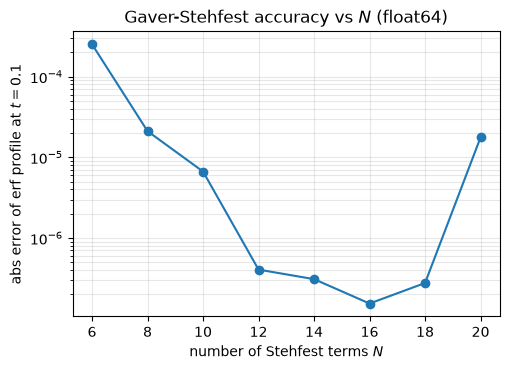

In [8]:
t_test = 0.1
exact = c_star * erf(x / (2.0 * np.sqrt(D * t_test)))
Ns = np.array([6, 8, 10, 12, 14, 16, 18, 20])
errs = np.array([abs(stehfest_invert(cbar_step, t_test, N=int(N))[0] - exact)
                 for N in Ns])
for N, e in zip(Ns, errs):
    print(f"N = {N:2d}:  abs err = {e:.2e}")

# The error must improve substantially from small N to the float64 sweet spot.
assert errs[Ns == 14][0] < errs[Ns == 6][0] / 10.0
print("PASS: error at N=14 is >10x smaller than at N=6 (convergence).")

fig, ax = plt.subplots(figsize=(5.2, 3.8))
ax.semilogy(Ns, errs, "o-", color="C0")
ax.set_xlabel("number of Stehfest terms $N$")
ax.set_ylabel("abs error of erf profile at $t=0.1$")
ax.set_title("Gaver-Stehfest accuracy vs $N$ (float64)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## A figure: numerical inversion overlaid on the analytic erf profiles

This reproduces the spirit of the book's final figure (the Stehfest points, shown as markers,
sitting on the exact erf curves, shown as lines, across four decades of time),
regenerated entirely in matplotlib from our own implementation.

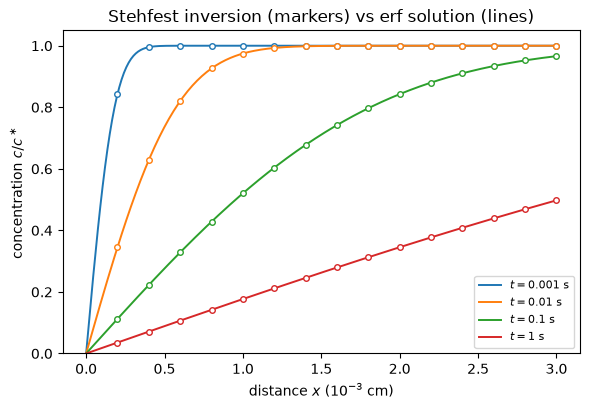

In [9]:
x_plot = np.linspace(0.0, 3e-3, 200)
times = [0.001, 0.01, 0.1, 1.0]

fig, ax = plt.subplots(figsize=(6, 4.2))
for tt, col in zip(times, ["C0", "C1", "C2", "C3"]):
    # analytic
    ax.plot(x_plot * 1e3, c_star * erf(x_plot / (2 * np.sqrt(D * tt))),
            color=col, lw=1.4, label=fr"$t={tt:g}$ s")
    # Stehfest at sparse markers
    xs = np.linspace(0.0, 3e-3, 16)[1:]        # skip x=0 (trivially 0)
    cs = np.array([stehfest_invert(
        lambda s, xv=xv: c_star / s - c_star * np.exp(-np.sqrt(s / D) * xv) / s,
        tt, N=16)[0] for xv in xs])
    ax.plot(xs * 1e3, cs, "o", color=col, ms=4, mfc="white")
ax.set_xlabel(r"distance $x$ (10$^{-3}$ cm)")
ax.set_ylabel(r"concentration $c/c^\ast$")
ax.set_title("Stehfest inversion (markers) vs erf solution (lines)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

We re-implemented the **Gaver–Stehfest** numerical Laplace inversion from its
defining weight series and exercised it on:

* elementary pairs $1/s\!\to\!1$ and $1/(s+a)\!\to\!e^{-at}$ (closed-form),
* the semi-infinite potential-step concentration profile, recovering the exact
  $\mathrm{erf}$ solution, and
* the surface flux, recovering the **Cottrell** current and matching
  `serm.echem.cottrell_current` dimensionally,

and we mapped its accuracy-versus-$N$ behaviour, confirming the float64 sweet spot
near $N=14\text{–}16$. This gives a drop-in tool for the many later problems
(finite/thin-layer and spherical geometries, coupled kinetics) whose transforms
are known but whose inverses are not tabulated.

<!-- nav-footer -->

---

[← Chapter 1 — Solving PDEs in Electrochemistry](../01_solving_pdes.ipynb)

[Contents (README)](../../README.md)